In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import os
import sys
import pickle

In [2]:
data_directory = '/mnt/Data/Behavioural_Data/Bpod_data/'
experiment_name = 'D-AP5-Chronic-Infusion-SP120-137_Aug23_Analysis'
data_path = os.path.join(data_directory, experiment_name)
save_path = os.path.join(data_path, 'plots')

In [3]:
# list all the .pkl files in the current directory

pkl_files = [file for file in os.listdir(data_path) if file.endswith('.pkl')]

print(pkl_files)

['D-AP5-Chronic-Infusion-SP120-137_Aug23_dataframe.pkl']


In [4]:
# list pickle files in the data_path and load them as dictionaries
data_file = os.path.join(data_path, pkl_files[0])
with open(data_file, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

Index(['AnimalID', 'ExperimentalGroup', 'SessionTime', 'FullSessionTime',
       'Protocol', 'Stimulation', 'Muscimol', 'RewardChange',
       'RewardChangeBlock', 'CenterPortDuration', 'Contingency',
       'RewardAmount', 'PunishDelay', 'Punish', 'BiasCorrection', 'TrialIndex',
       'TrialHighPerc', 'Outcomes', 'OptoStim', 'FirstPokeCorrect',
       'FirstPoke', 'TrialSide', 'TrialSequence', 'ResponseTime',
       'TrialStartTimestamp', 'CumulativePerformance', 'SwitchSide',
       'PreviousChoice', 'TrialEvents', 'TrialStates', 'FullGUI', 'SessionID',
       'ITIs', 'CumulativeTrialNumber', 'CumulativeTrialNumberByProtocol',
       'CurrentPastPerformance20', 'CurrentPastPerformance100',
       'NoOfCenterPokes', 'MiddleWaitTime', 'TrialInitiationTime', 'RightBias',
       'TrialsSpeed', 'PrevTrialSuccess'],
      dtype='object')


In [5]:
# convert the dictionary to a dataframe
df = pd.DataFrame(data)
df.head()

,AnimalID,ExperimentalGroup,SessionTime,FullSessionTime,Protocol,Stimulation,Muscimol,RewardChange,RewardChangeBlock,CenterPortDuration,...,CumulativeTrialNumber,CumulativeTrialNumberByProtocol,CurrentPastPerformance20,CurrentPastPerformance100,NoOfCenterPokes,MiddleWaitTime,TrialInitiationTime,RightBias,TrialsSpeed,PrevTrialSuccess
0,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,1,1.0,NaN,NaN,1,0.036407,290.7158,NaN,NaN,NaN
14,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,2,2.0,NaN,NaN,1,0.210900,NaN,NaN,NaN,0.0
17,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,3,3.0,NaN,NaN,1,0.349400,38.5954,NaN,1.313154,1.0
27,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,4,4.0,NaN,NaN,1,0.063000,49.1914,NaN,1.756277,1.0
34,SP120,D-AP5,May26 16:24,2023-05-26 16:24:00,Habituation,NoStimulation,No,No,0,0.03,...,5,5.0,NaN,NaN,1,0.058800,8.2032,NaN,1.751116,1.0


In [6]:
# here write code to drop outliers (in this case we want to remove all AnimalID=SP124)

# # drop all rows with AnimalID=SP124
# df = df[df.AnimalID != 'SP124']
# df.head()

# print all unique animal IDs
print(df.AnimalID.unique())


['SP120' 'SP121' 'SP122' 'SP124' 'SP126' 'SP138' 'SP139' 'SP140' 'SP132'
 'SP133' 'SP134' 'SP135' 'SP136' 'SP137']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 125786 entries, 0 to 137238
Data columns (total 43 columns):
AnimalID                           125786 non-null object
ExperimentalGroup                  125786 non-null object
SessionTime                        125786 non-null object
FullSessionTime                    125786 non-null datetime64[ns]
Protocol                           125786 non-null object
Stimulation                        125786 non-null object
Muscimol                           125786 non-null object
RewardChange                       125786 non-null object
RewardChangeBlock                  125786 non-null int64
CenterPortDuration                 125786 non-null float64
Contingency                        125786 non-null int64
RewardAmount                       125786 non-null int64
PunishDelay                        125786 non-null float64
Punish                             125786 non-null object
BiasCorrection                     125786 non-null int64
TrialIndex   

In [8]:


def plot_cumulative_performance(df, protocol='Auditory', max_trial_number=3000, 
                                group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                error_transparency=0.03, exclude_animal_ids=[]):
    """
    Plots the Cumulative Performance for a given protocol.

    Parameters:
    - df: DataFrame containing the data.
    - protocol: Protocol type to filter data on.
    - max_trial_number: Maximum trial number to consider for filtering.
    - group_colors: Dictionary specifying the colors for the experimental groups.
    - error_transparency: Transparency level for the shaded error bars.
    - exclude_animal_ids: List of AnimalIDs to be excluded.
    """
    
    # Filter out specific AnimalIDs
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Filter the data
    filtered_df = df[(df['Protocol'] == protocol) & (df['CumulativeTrialNumberByProtocol'] <= max_trial_number)]

    # Group by the relevant columns and compute mean and standard deviation
    grouped = filtered_df.groupby(['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'])['CumulativePerformance']
    
    mean_df = grouped.mean().reset_index().rename(columns={'CumulativePerformance': 'MeanPerformance'})
    std_df = grouped.std().reset_index().rename(columns={'CumulativePerformance': 'StdPerformance'})
    
    # Smooth the calculated means and standard deviations, performance was calculated by Hernando by taking movmean of past 100 trials
    window_size = 50
    for group in mean_df['ExperimentalGroup'].unique():
        mask = mean_df['ExperimentalGroup'] == group
        mean_df.loc[mask, 'SmoothedPerformance'] = mean_df[mask]['MeanPerformance'].rolling(window=window_size, center=True).mean()
        std_df.loc[mask, 'SmoothedStd'] = std_df[mask]['StdPerformance'].rolling(window=window_size, center=True).mean()

    # Merge the smoothed performances and std deviations back to the filtered dataframe
    filtered_df = pd.merge(filtered_df, mean_df, on=['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'], how='left')
    filtered_df = pd.merge(filtered_df, std_df, on=['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'], how='left')

    # Plotting
    sns.set_style("whitegrid")
    aspect_ratio = 16/9
    plt.figure(figsize=(10, 10/aspect_ratio))
    
    sns.lineplot(x='CumulativeTrialNumberByProtocol', y='SmoothedPerformance', hue='ExperimentalGroup', data=filtered_df, palette=group_colors)
    
    # For the shading based on smoothed std
    for group, color in group_colors.items():
        group_data = filtered_df[filtered_df['ExperimentalGroup'] == group]
        plt.fill_between(group_data['CumulativeTrialNumberByProtocol'], 
                         group_data['SmoothedPerformance'] - group_data['SmoothedStd'], 
                         group_data['SmoothedPerformance'] + group_data['SmoothedStd'], 
                         color=color, alpha=error_transparency)

    # Add horizontal lines with increased transparency
    for y in [50, 100]:
        plt.axhline(y=y, color='gray', linestyle='--', alpha=0.5)

    plt.title('Cumulative Performance by Experimental Group')
    plt.xlabel('Trial number')
    plt.ylabel('Performance (%)')
    plt.grid(False)
    plt.ylim(35, 105)
    plt.xlim(-10, max_trial_number)
    plt.xticks(np.arange(0, max_trial_number+1, 500))
    plt.yticks(np.arange(40, 101, 10))

    # Adjust spines to only show the bottom and left
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Adjust the legend position to avoid overlap
    plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.9))
    
    plt.tight_layout()
    plt.show()

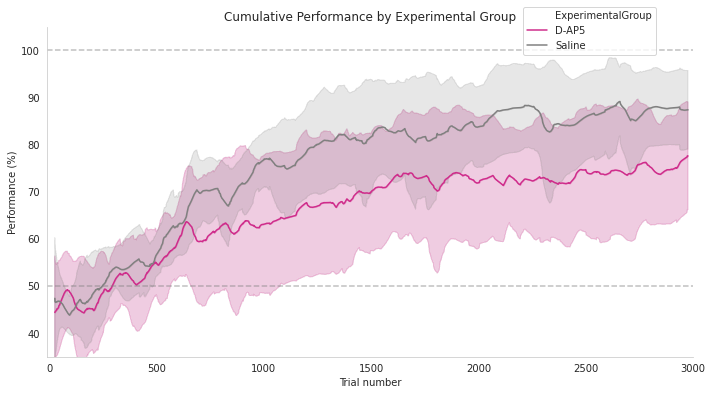

In [9]:

# plot cumulative performance
plot_cumulative_performance(df, protocol='Auditory', max_trial_number=3000, 
                                group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                error_transparency=0.03, exclude_animal_ids=[])


In [10]:
def perf_window_calculator(firstpokecorrect, window):
    """
    Calculate the performance of the last X trials
    This is a function written by Hernando and used in APE paper (Greenstreet et al., 2022 for analysis)
    """
    perf_window = np.full(len(firstpokecorrect), np.nan)
    for i in range(len(perf_window)):
        if i < window:
            # For the first window-1 trials, dynamically adjust the window size
            current_window_size = i + 1
            perf_window[i] = np.nansum(firstpokecorrect[:i+1]) / current_window_size * 100
        else:
            perf_window[i] = np.nansum(firstpokecorrect[i - window + 1: i + 1]) / window * 100
    return perf_window

def plot_cumulative_performance_last_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                                group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                                error_transparency=0.03, exclude_animal_ids=[], window=100,
                                                save_path=save_path, suffix='cumulative_performance.SVG'):
    """
    Plots the Cumulative Performance for a given protocol and saves it as SVG.

    Parameters:
    ...
    - save_path: The directory path where the SVG files will be saved.
    """
    # Filter out specific AnimalIDs
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Filter the data and make a copy to avoid SettingWithCopyWarning
    filtered_df = df[(df['Protocol'] == protocol) & 
                     (df['CumulativeTrialNumberByProtocol'] <= max_trial_number)].copy()
    
    # Apply the performance window calculation
    filtered_df['WindowedPerformance'] = perf_window_calculator(filtered_df['FirstPokeCorrect'].values, window)

    # Group by the relevant columns and compute mean and standard deviation
    grouped = filtered_df.groupby(['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'])['WindowedPerformance']
    mean_df = grouped.mean().reset_index().rename(columns={'WindowedPerformance': 'MeanPerformance'})
    std_df = grouped.std().reset_index().rename(columns={'WindowedPerformance': 'StdPerformance'})

    # Merge the performances and std deviations back to the filtered dataframe
    filtered_df = pd.merge(filtered_df, mean_df, on=['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'], how='left')
    filtered_df = pd.merge(filtered_df, std_df, on=['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'], how='left')

    # Plotting
    sns.set_style("whitegrid")
    aspect_ratio = 16/9
    plt.figure(figsize=(10, 10/aspect_ratio))
    
    # Filter data to exclude the first 100 trials for plotting
    plot_df = filtered_df[filtered_df['CumulativeTrialNumberByProtocol'] >= 100]
    
    sns.lineplot(x='CumulativeTrialNumberByProtocol', y='WindowedPerformance', hue='ExperimentalGroup', data=plot_df, palette=group_colors)
    
    # For the shading based on standard deviations
    for group, color in group_colors.items():
        group_data = plot_df[plot_df['ExperimentalGroup'] == group]
        plt.fill_between(group_data['CumulativeTrialNumberByProtocol'], 
                         group_data['MeanPerformance'] - group_data['StdPerformance'], 
                         group_data['MeanPerformance'] + group_data['StdPerformance'], 
                         color=color, alpha=error_transparency)

    # Additional formatting and plotting configurations
    for y in [50, 100]:
        plt.axhline(y=y, color='gray', linestyle='--', alpha=0.5)

    plt.title('Cumulative Performance by Experimental Group')
    plt.xlabel('Trial number')
    plt.ylabel('Performance (%)')
    plt.grid(False)
    plt.ylim(30, 105)
    plt.xlim(-10, max_trial_number)
    plt.xticks(np.arange(0, max_trial_number+1, 500))
    plt.yticks(np.arange(40, 101, 10))

    # Adjust spines to only show the bottom and left
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Adjust the legend position to avoid overlap
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    
    # Check if save_path is provided and save the plot as SVG
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.savefig(os.path.join(save_path, suffix), format='svg', dpi=300, bbox_inches='tight')
    else:
        plt.show()



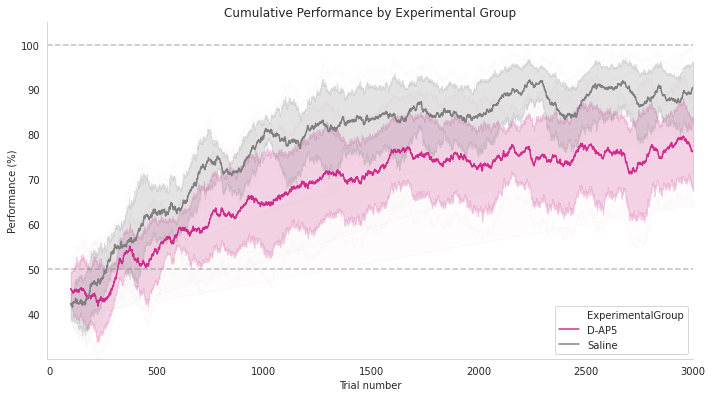

In [15]:
plot_cumulative_performance_last_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                error_transparency=0.01, exclude_animal_ids=[], window=100, save_path=save_path, suffix='cumulative_performance_without_outlier.SVG')


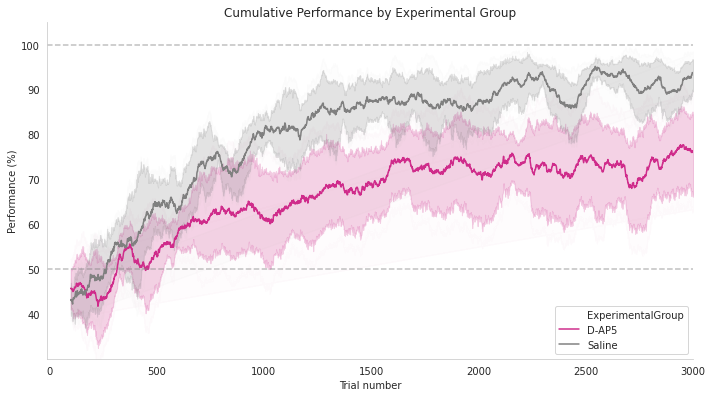

In [16]:
plot_cumulative_performance_last_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                error_transparency=0.01, exclude_animal_ids=['SP124', 'SP133'], window=100)

In [46]:
def plot_performance_by_animals_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                            group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                            error_transparency=0.03, exclude_animal_ids=[], bin_size=200, window=100,
                                            save_path=None, suffix='performance_by_animals.SVG'):
    """
    Plots the Cumulative Performance for a given protocol for each unique AnimalID, colored by their ExperimentalGroup.
    The plot points are averaged every 'bin_size' number of trials.

    Parameters:
    ...
    - bin_size: The number of trials to average together.
    """
    
    # Filter out specific AnimalIDs
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Filter the data for the specified protocol and trial number
    filtered_df = df[(df['Protocol'] == protocol) & 
                     (df['CumulativeTrialNumberByProtocol'] <= max_trial_number)].copy()
    
    # Calculate the windowed performance
    filtered_df['WindowedPerformance'] = perf_window_calculator(filtered_df['FirstPokeCorrect'].values, window=window)

    # Filter data to exclude the first 100 trials for plotting
    plot_df = filtered_df.loc[filtered_df['CumulativeTrialNumberByProtocol'] >= 100].copy()

    # Group the trials by every 'bin_size' number of trials
    # Use .loc to ensure you're working on a copy and avoid SettingWithCopyWarning.
    plot_df.loc[:, 'TrialGroup'] = (plot_df['CumulativeTrialNumberByProtocol'] - 100) // bin_size

    # Calculate the mean performance for each group
    plot_df = plot_df.groupby(['AnimalID', 'ExperimentalGroup', 'TrialGroup']).agg({
        'WindowedPerformance': 'mean',
        'CumulativeTrialNumberByProtocol': 'min'  # Take the min trial number of the group for plotting
    }).reset_index()

    # Plotting with seaborn lineplot within a loop for each animal
    sns.set_style("whitegrid")
    aspect_ratio = 16/9
    plt.figure(figsize=(10, 10/aspect_ratio))
    
    # Plot each animal's data as a separate lineplot
    for animal_id in plot_df['AnimalID'].unique():
        animal_data = plot_df[plot_df['AnimalID'] == animal_id]
        group = animal_data['ExperimentalGroup'].iloc[0]  # assuming all rows have the same group for this animal
        sns.lineplot(
            data=animal_data,
            x='CumulativeTrialNumberByProtocol',
            y='WindowedPerformance',
            color=group_colors[group]
        )
    
    # Create a proxy artist for the legend (to ensure only ExperimentalGroup names are displayed and not AnimalIDs)
    legend_handles = [plt.Line2D([0], [0], color=color, label=group) for group, color in group_colors.items()]

    # Additional formatting and plotting configurations
    for y in [50, 100]:
        plt.axhline(y=y, color='gray', linestyle='--', alpha=0.5)

    plt.title('Cumulative Performance by Animal')
    plt.xlabel('Trial number')
    plt.ylabel('Performance (%)')
    plt.grid(False)
    plt.ylim(10, 105)
    plt.xlim(-10, max_trial_number)
    plt.xticks(np.arange(0, max_trial_number+1, 500))
    plt.yticks(np.arange(40, 101, 10))

    # Adjust spines to only show the bottom and left
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Adjust the legend
    plt.legend(handles=legend_handles)
    
    plt.tight_layout()

    # Check if save_path is provided and save the plot as SVG
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.savefig(os.path.join(save_path, suffix), format='svg', dpi=300, bbox_inches='tight')
    else:
        plt.show()

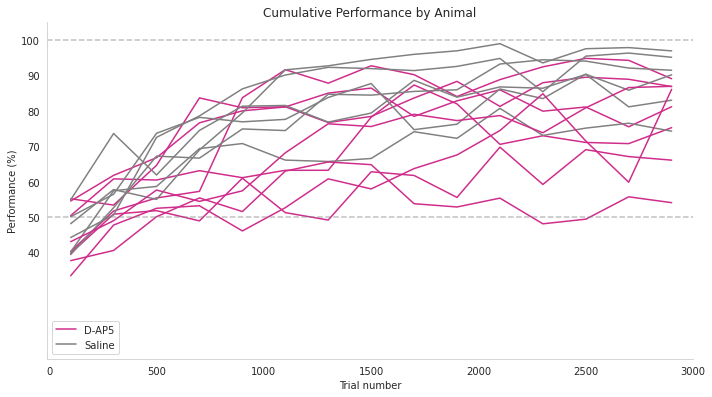

In [47]:
plot_performance_by_animals_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                            group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                            error_transparency=0.03, exclude_animal_ids=[], bin_size=200, window=100,
                                            save_path=save_path, suffix='performance_by_animals_without_outlier.SVG')

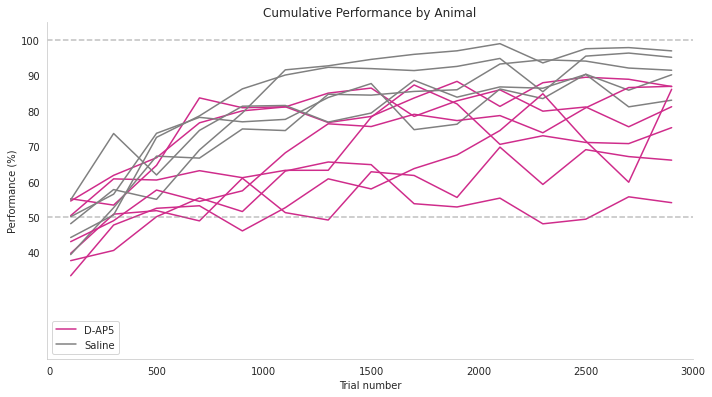

In [48]:
plot_performance_by_animals_trialwindow(df, protocol='Auditory', max_trial_number=3000, 
                                            group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                            error_transparency=0.03, exclude_animal_ids=['SP124', 'SP133'], bin_size=200, window=100,
                                            save_path=save_path, suffix='performance_by_animals.SVG')

In [16]:
## Here plot maximum task performance as bar graphs for each ExperimentGroup

In [72]:
def plot_mean_difference_by_trials(df, protocol='Auditory', max_trial_number=3000,
                                   group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                   exclude_animal_ids=[], window=100, bin_size=100, n_shuffles=1000, seed=None,
                                   save_path=None, suffix='mean_difference.svg'):
    """
    Plots the difference in mean performance between experimental groups for a given protocol over trials.
    Also includes confidence intervals from shuffled data.

    Parameters:
    ...
    - bin_size: Number of trials to average for plotting.
    - n_shuffles: Number of shuffles for generating confidence intervals.
    - seed: Seed for reproducibility.
    - save_path: Path to save the plot, if None, the plot is shown but not saved.
    - suffix: Suffix for the saved plot file.
    """
    # Set seed
    np.random.seed(seed)
    
    # Filter out specific AnimalIDs
    if exclude_animal_ids:
        df = df[~df['AnimalID'].isin(exclude_animal_ids)]
    
    # Filter the data and make a copy to avoid SettingWithCopyWarning
    filtered_df = df[(df['Protocol'] == protocol) & 
                     (df['CumulativeTrialNumberByProtocol'] <= max_trial_number)].copy()
    
    # Apply the performance window calculation
    filtered_df['WindowedPerformance'] = perf_window_calculator(filtered_df['FirstPokeCorrect'].values, window)
    
    # Calculate mean performance per group before shuffling
    mean_df = filtered_df.groupby(['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'])['WindowedPerformance'].mean().reset_index()
    
    # Shuffling for confidence intervals
    shuffled_diffs = []
    for _ in range(n_shuffles):
        shuffled_df = filtered_df.copy()
        shuffled_df['ExperimentalGroup'] = np.random.permutation(shuffled_df['ExperimentalGroup'].values)
        shuffled_means = shuffled_df.groupby(['ExperimentalGroup', 'CumulativeTrialNumberByProtocol'])['WindowedPerformance'].mean().reset_index()
        
        # Resetting the trial indices and keeping common trials
        groups = shuffled_means['ExperimentalGroup'].unique()
        group1_data = shuffled_means[shuffled_means['ExperimentalGroup'] == groups[1]].reset_index(drop=True)
        group2_data = shuffled_means[shuffled_means['ExperimentalGroup'] == groups[0]].reset_index(drop=True)
        
        min_trials = min(len(group1_data), len(group2_data))
        group1_data = group1_data.head(min_trials)
        group2_data = group2_data.head(min_trials)
        
        group1_data['CumulativeTrialNumberByProtocol'] = range(len(group1_data))
        group2_data['CumulativeTrialNumberByProtocol'] = range(len(group2_data))

        shuffled_diff = group1_data.set_index('CumulativeTrialNumberByProtocol')['WindowedPerformance'] - \
                        group2_data.set_index('CumulativeTrialNumberByProtocol')['WindowedPerformance']
        shuffled_diffs.append(shuffled_diff)

    # Compute 95% CI
    all_diffs = pd.concat(shuffled_diffs, axis=1)
    lower_bound = all_diffs.quantile(0.025, axis=1)
    upper_bound = all_diffs.quantile(0.975, axis=1)

    # Binning the data and the confidence intervals
    def bin_data(series, bin_size):
        return series.groupby(np.arange(len(series)) // bin_size).mean()
    
    # Bin the mean_df performance data
    mean_df['BinnedTrial'] = mean_df['CumulativeTrialNumberByProtocol'] // bin_size
    mean_performance = mean_df.groupby(['ExperimentalGroup', 'BinnedTrial'])['WindowedPerformance'].mean().reset_index()

    # Resetting the trial indices and keeping common trials for the binned data
    groups = mean_performance['ExperimentalGroup'].unique()
    group1_binned = mean_performance[mean_performance['ExperimentalGroup'] == groups[0]].reset_index(drop=True)
    group2_binned = mean_performance[mean_performance['ExperimentalGroup'] == groups[1]].reset_index(drop=True)

    min_binned_trials = min(len(group1_binned), len(group2_binned))
    group1_binned = group1_binned.head(min_binned_trials)
    group2_binned = group2_binned.head(min_binned_trials)
    
    mean_difference = group1_binned['WindowedPerformance'] - group2_binned['WindowedPerformance']

    # Bin the confidence intervals
    binned_lower_bound = bin_data(lower_bound, bin_size)
    binned_upper_bound = bin_data(upper_bound, bin_size)
    
    # Ensure binned CI and mean_difference have same length
    min_length = min(len(binned_lower_bound), len(binned_upper_bound), len(mean_difference))
    mean_difference = mean_difference.head(min_length)
    binned_lower_bound = binned_lower_bound.head(min_length)
    binned_upper_bound = binned_upper_bound.head(min_length)

    # Plotting
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 10/16*9))

    x = np.arange(min_length) * bin_size
    plt.plot(x, mean_difference, color='darkcyan', linewidth=2, label='Observed data', linestyle='-')

    # Plot the upper and lower bounds as black dotted lines
    plt.plot(x, binned_lower_bound, 'k--', alpha=0.5, label='95% CI')
    plt.plot(x, binned_upper_bound, 'k--', alpha=0.5, label='')

    # Fill between mean_difference and binned_lower_bound conditionally
    plt.fill_between(x, mean_difference, binned_lower_bound, where=(mean_difference < binned_lower_bound), 
                     color='darkcyan', alpha=0.2, interpolate=True)

    # Formatting
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.title(f'{protocol} Protocol - Performance Difference Over Trials')
    plt.xlabel('Trials')
    plt.ylabel('Performance Difference (%)')
    plt.legend(loc='upper right', frameon=True)

    # Adjust the x-axis limit to accommodate binning
    plt.xlim(0, (min_length-1)*bin_size)
    plt.ylim(-30, max(30, max(mean_difference.max(), binned_upper_bound.max()) + 10))

    # switch off grid
    plt.grid(False)

    plt.tight_layout()

    # Check if save_path is provided and save the plot
    if save_path:
        if not os.path.exists(save_path):
            os.makedirs(save_path)
        plt.savefig(os.path.join(save_path, suffix), format='svg', dpi=300, bbox_inches='tight')
    else:
        plt.show()

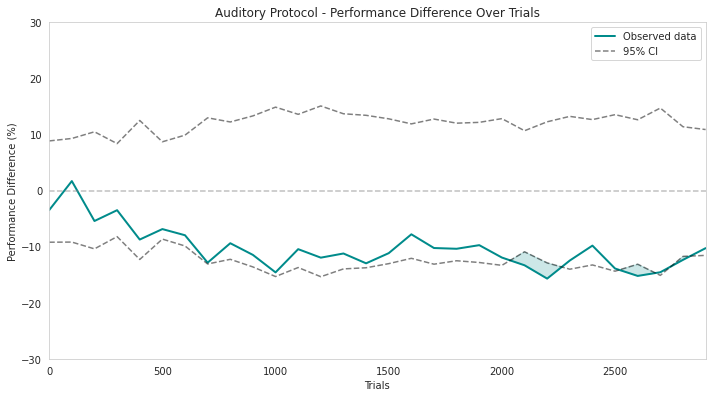

In [74]:
plot_mean_difference_by_trials(df, protocol='Auditory', max_trial_number=3000,
                                   group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                   exclude_animal_ids=[], window=100, bin_size=100, n_shuffles=10000, seed = 0,
                                   save_path=save_path, suffix='mean_difference_without_outlier.SVG')

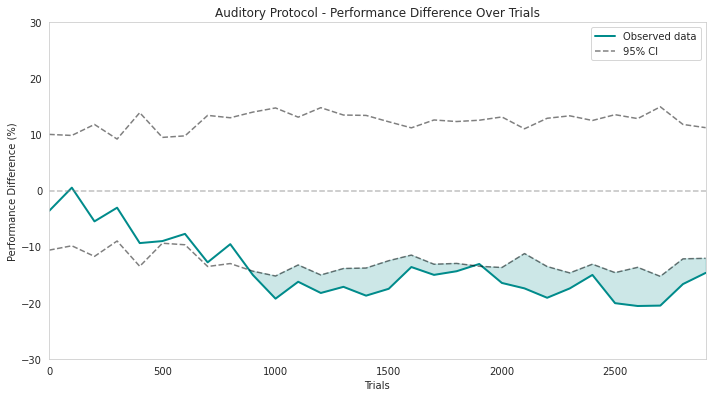

In [75]:
plot_mean_difference_by_trials(df, protocol='Auditory', max_trial_number=3000,
                                   group_colors={'D-AP5': '#cf2c8b', 'Saline': '#808080'}, 
                                   exclude_animal_ids=['SP124', 'SP133'], window=100, n_shuffles=10000, seed = 0,
                                   save_path=save_path, suffix='mean_difference.SVG')